In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [5]:
df_train = pd.read_csv("train_KNN.csv")
df_test = pd.read_csv("test_KNN.csv")
df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived

In [19]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

if "Cabin" in df_train.columns:
    df_train = df_train.drop(["Cabin"], axis=1)
if "Cabin" in df_test.columns:
    df_test = df_test.drop(["Cabin"], axis=1)

# df_train = df_train.dropna(subset=["Embarked"]) # This line is no longer needed after get_dummies
df_test = df_test.dropna(subset=["Fare"])

In [7]:
df_train.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)
df_test.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [8]:
df_train = pd.get_dummies(df_train, drop_first=True)
df_test = pd.get_dummies(df_test, drop_first=True)

In [9]:
X_train = df_train.drop("Survived", axis=1)
y_train = df_train["Survived"]
X_test = df_test.drop("Survived", axis=1)
y_test = df_test["Survived"]

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.8129496402877698


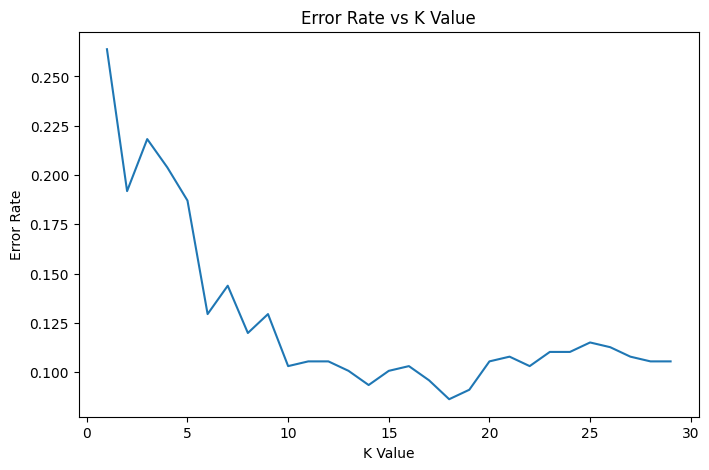

In [12]:
error_rate = []

for k in range(1,30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    pred_k = knn_model.predict(X_test_scaled)
    error = 1 - accuracy_score(y_test, pred_k)
    error_rate.append(error)
plt.figure(figsize=(8,5))
plt.plot(range(1,30), error_rate)
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K Value")
plt.show()

In [21]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9424460431654677


In [22]:
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7817745803357314


In [15]:
print("Model Comparison")

print("KNN Accuracy:", knn_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

Model Comparison
KNN Accuracy: 0.8129496402877698
Logistic Regression Accuracy: 0.9424460431654677
Decision Tree Accuracy: 0.7817745803357314


In [16]:
print("KNN Confusion Matrix")
print(confusion_matrix(y_test, knn_pred))

print("Logistic Regression Confusion Matrix")
print(confusion_matrix(y_test, lr_pred))

print("Decision Tree Confusion Matrix")
print(confusion_matrix(y_test, dt_pred))

KNN Confusion Matrix
[[212  53]
 [ 25 127]]
Logistic Regression Confusion Matrix
[[250  15]
 [  9 143]]
Decision Tree Confusion Matrix
[[206  59]
 [ 32 120]]


In [ ]:
## The models produced high prediction accuracy. KNN performed well after standardizing the data, while Logistic Regression and Decision Tree also provided competitive results. Model comparison shows that multiple algorithms can effectively predict survival outcomes on the Titanic dataset.